# Performance benchmarks

This notebook provides performance benchmarks for EVoC in comparison to some commonly used options for embedding vector clustering. The goal of these benchmarks is not to be comprehensive, but rather to give a sense of where EVoC's strengths lie, particulary as compared with other standard options. The aim is to look at both clustering quality and compute time and focus primarily on real-world datasets. To ensure you can try running these benchmarks on your hardware we will provide all the code to run the benchmarks yourself. So to start let's get all the libraries we'll need, both to run the benchmarks and comparisons, and visualise the results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import evoc
import umap
import hdbscan
import pandas as pd
import sklearn.cluster
import sklearn.metrics
import warnings
warnings.filterwarnings("ignore")

Now we will need come clustering alternatives to compare to. There are, of course, an endless array of clustering algorithms and implementations out there, but for the purposes of giving a basic comparison we will focus on the most common options for embedding vector clustering, such as those used in BERTopic. That means we'll need an implementation of UMAP + HDBSCAN for comparison, and we'll also compare with the standard workhorse: sklearn's KMeans. Sine we'll be benchmarking these we'll build a common calling format so we can build a benchmark harness around them easily. We'll start with UMAP + HDBSCAN which requires a little bit of work to glue together. 

In [2]:
def umap_hdbscan(
    data,
    metric="euclidean",
    n_neighbors=15,
    n_components=2,
    min_samples=5,
    min_cluster_size=10,
    min_dist=0.1,
    cluster_selection_method="eom",
    n_epochs=None,
    negative_sample_rate=5,
):
    embedding = umap.UMAP(
        metric=metric,
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        n_epochs=n_epochs,
        negative_sample_rate=negative_sample_rate,
        n_jobs=8,
    ).fit_transform(data)
    clustering = hdbscan.HDBSCAN(
        min_samples=min_samples,
        min_cluster_size=min_cluster_size,
        cluster_selection_method=cluster_selection_method,
    ).fit_predict(embedding)
    return clustering

Next up is KMeans. We don't need much of a wrapper here -- we can call on sklearn's implementation fairly directly.

In [3]:
def kmeans(data, n_clusters=10, kmeans_algorithm="lloyd"):
    return sklearn.cluster.KMeans(
        n_clusters=n_clusters, 
        n_init="auto", 
        algorithm=kmeans_algorithm
    ).fit_predict(
        data
    )

Lastly we need an EVoC function that works with the same pattern. We'll even be sure to use the reproducible (fixed ``random_state``) code-path that is a little slower, but vary the seed to ensure we get variation in results. Since EVoC can provide a few layers of clustering, we'll give it a little bonus by selecting out the best cluster layer compared to a target clustering. In practice EVoC usually selects a very good cluster layer, but for some of the datasets we'll be using the class labels are not exactly the most natural clustering, so we'll let the function choose a different layer in those cases. Note that we are not tuning any other EVoC parameters to optimize the results, just using defaults and selecting among the layers produced (usally 2-5 total layers for any of these datasets, so few enough that you could easily look througbn them by hand). In contrast we did spend time tuning parameters for the other algorithms to try to produce the best accuracy/quality scores we could. Sometimes this involved non-obvious choices of parameters.

In [4]:
def EVoC(data, test_target=None, random_state=None):
    if random_state is None:
        random_state = np.random.randint(65536)
    cls = evoc.EVoC(random_state=random_state).fit(data)
    if test_target is None:
        return cls.labels_
    result = np.full(data.shape[0], -1)
    best_ari = 0.0
    for labels in cls.cluster_layers_:
        ari = sklearn.metrics.adjusted_rand_score(
            test_target[labels >= 0], labels[labels >= 0]
        )
        if ari > best_ari:
            best_ari = ari
            result = labels
    return result

Now we need a test harness. To asses the quality of a clustering we'll use datasets that come equipped with class labels, and specifically datasets where there is good reason to expect that the clusters should align reasonably with the class labels. This let's us use robust scores such as Adjusted Rand Index (ARI) and Adjusted Mutual Information (AMI) that compare a clustering against ground-truth labels. Since both UMAP + HDBSCAN and EVoC have a notion of noise points we'll exclude those from the ARI and AMI computations (as they don't make sense as a single class, and confuse things). But we will keep track of how much of the data is clustered, and also track a "clustering score" that is a weighted geometric mean of the ARI and the amount of data clustered (weighted 2:1 in favour of ARI accuracy, so we mostly care about being right, but also need to cluster a reasonable amount of data). We will also keep track of how long it takes to run any of these methods.

In [5]:
def score_clustering(data, target, clustering_function, n_runs=16, **kwargs):
    result = np.zeros((n_runs, 5), dtype=np.float32)
    for i in range(n_runs):
        start_time = time.time()
        clustering = clustering_function(data, **kwargs)
        result[i, 0] = time.time() - start_time
        result[i, 1] = sklearn.metrics.adjusted_rand_score(
            target[clustering >= 0], clustering[clustering >= 0]
        )
        result[i, 2] = sklearn.metrics.adjusted_mutual_info_score(
            target[clustering >= 0], clustering[clustering >= 0]
        )
        result[i, 3] = np.sum(clustering >= 0) / clustering.shape[0]
        result[i, 4] = np.cbrt((result[i, 1] ** 2) * result[i, 3])

    result = pd.DataFrame(
        result,
        columns=(
            "Elapsed time",
            "Adjusted Rand Index",
            "Adjusted Mutual Information",
            "Proportion clustered",
            "Clustering Score",
        ),
    )
    result["algorithm"] = clustering_function.__name__.replace("_", "\n")
    result = result.melt(
        id_vars=["algorithm"],
        value_vars=[
            "Elapsed time",
            "Adjusted Rand Index",
            "Adjusted Mutual Information",
            "Proportion clustered",
            "Clustering Score",
        ],
        var_name="measure",
    )
    return result

Lastly we'll need a simple function to run all our clustering algorithm benchmarks for each method across a given dataset and provide a nice table of results that we can easily pass to seaborn for plotting.

In [6]:
def run_dataset_benchmarks(data, target, n_runs, kmeans_kwargs, umap_hdbscan_kwargs):
    """Score all three algorithms on a dataset and return combined results."""
    kmeans_results = score_clustering(
        data, target, kmeans, n_runs=n_runs, **kmeans_kwargs
    )
    umap_results = score_clustering(
        data, target, umap_hdbscan, n_runs=n_runs, **umap_hdbscan_kwargs
    )
    evoc_results = score_clustering(
        data, target, EVoC, test_target=target, n_runs=n_runs
    )
    return pd.concat(
        [kmeans_results, umap_results, evoc_results.assign(algorithm="EVoC")],
        ignore_index=True,
    )

## Image embeddings

Let's start by looking at image embeddings. For a "real-world" dataset we'll use the tried and true CIFAR-100 dataset. The CIFAR-100 dataset is a popular computer vision benchmark containing 60,000 32x32 color images across 100 classes. In our case we don't need to worry about the images themselves, but rather their embeddings. We have built a dataset with embedding vectors generated by CLIP and provided it on Huggingface datasets so we don't have to worry about the time/cost of embedding all the images. If you wish you can generate your own embeddings, potentially with other models such as SigLIP. Let's pull that data down. 

In [7]:
from datasets import load_dataset

In [8]:
ds_cifar = load_dataset("lmcinnes/evoc_bench_cifar100")
cifar_data = np.asarray(ds_cifar["train"]["embedding"])
cifar_target = np.asarray(ds_cifar["train"]["target"])

Now we just need to run the benchmarks. Here we had to rune parameters a little. Oddly enough KMeans actually works better if you ask for 125 clusters (instead of the 100 classes that exist) because with more clusters it does a better job of breaking up some of the more easily confused classes that otherwise notably drag down ARI scores. For UMAP + HDBSCAN we need to manage pick the right parameters; in general UMAP doesn't need too much tuning for this, but HDBSCAN works best with leaf clustering and a carefully well-chosen ``min_cluster_size``. A little experimentation finds around 120 works well for this data.

In [9]:
cifar_results = run_dataset_benchmarks(
    cifar_data, 
    cifar_target, 
    n_runs=16, 
    kmeans_kwargs={"n_clusters":125}, 
    umap_hdbscan_kwargs={
        "min_samples":5,
        "min_cluster_size":120, 
        "metric":"cosine", 
        "cluster_selection_method":"leaf"
    }
)

Before we look at quality, let's compare how long these different approaches took to run:

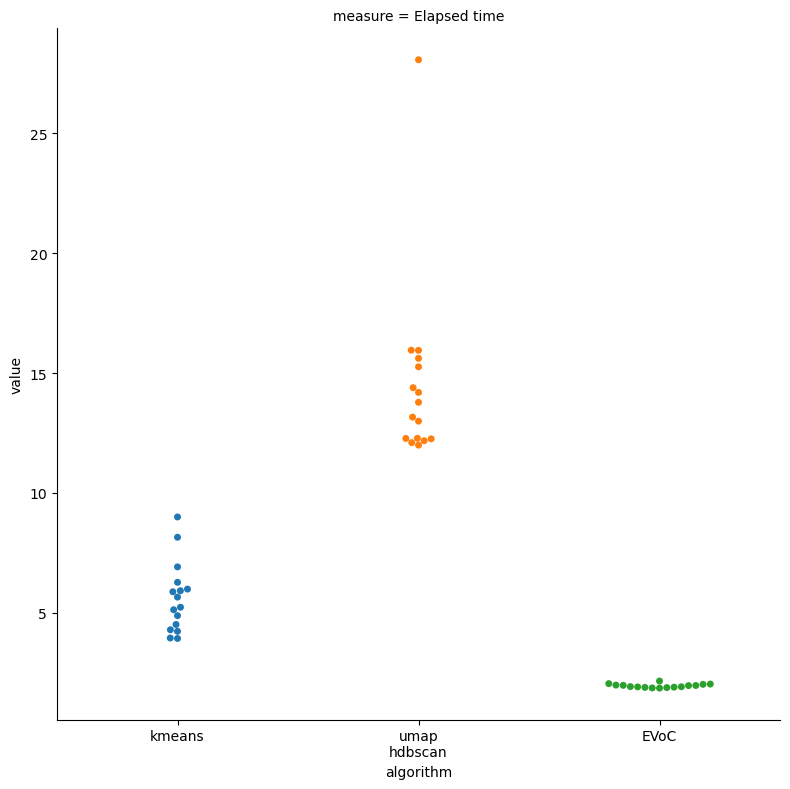

In [10]:
sns.catplot(
    cifar_results[cifar_results.measure == "Elapsed time"], 
    x="algorithm", 
    y="value", 
    hue="algorithm", 
    kind="swarm", 
    col="measure",
    height=8,
)

As expected KMeans is noticeably quicker than UMAP + HDBSCAN. The one very long time for UMAP + HDBSCAN is due to numba's JIT compilation time (subsequent runs don't require compilation -- so we won't see this again). The surprise is that EVoC actually ran faster than KMeans here. Often KMeans is chosen simply based on runtime-constraints: it is usually faster than most other options you could pick. Here, however, we see that EVoC is not only competitive with KMeans, it's actually the faster option!

How about the quality of the clusterings we get out?

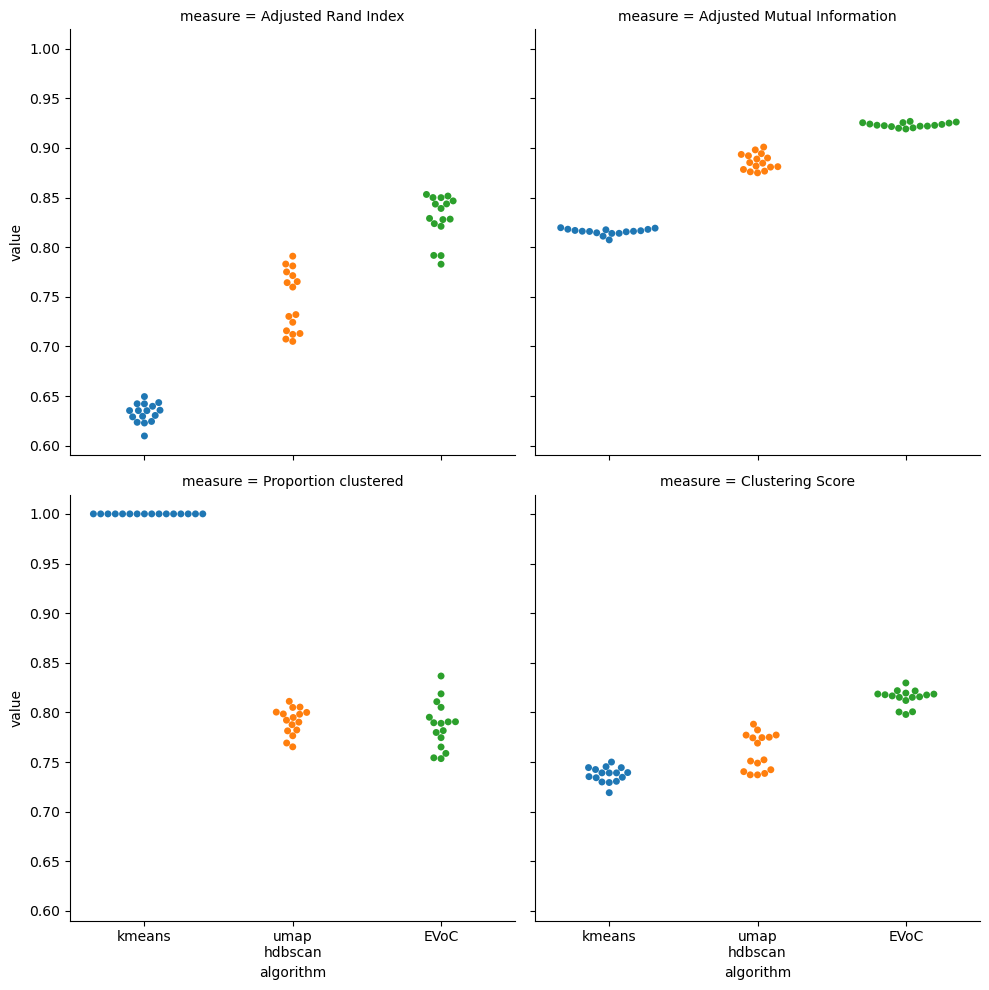

In [11]:
sns.catplot(
    cifar_results[cifar_results.measure != "Elapsed time"], 
    x="algorithm", 
    y="value", 
    hue="algorithm", 
    col="measure", 
    kind="swarm", 
    col_wrap=2,
    height=5,
)

Here we seem some of KMeans weakness -- it can run very fast, but the quality of the clusters is not always that great, particularly for very high dimensional data such as that produced by embedding models. The one upside of KMeans is that it does cluster all of your data, so the "proportion clustered" is perfect, and this significantly improves the clustering score since the other algoirithms only clustered around 80% of the data (but found much cleaner more accurate clusters by doing so). In contrast UMAP + HDBSCAN was much slower than KMeans, and we hope it managed to produce better clusters by doing so. And that is largely born out here. The ARI and AMI for UMAP + HDBSCAN are significantly better than KMeans, so we produced better clusters by expending more compute. Of course this did require not clustering 20% of the data -- but that 20% is likely the "hard to classify" samples that would simply make the ARI and AMI a lot worse if we tried to force them to be assigned somewhere. That means that on clustering score UMAP + HDBSCAN comes out a little ahead of KMeans. Last we have EVoC, which ran faster than KMeans and yet somehow also produced better clusters than UMAP + HDBSCAN. EVoC's edge in clustering quality over UMAP + HDBSCAN is not huge here, but it is relevant. The real strength of EVoC on this dataset is the raw speed with which it can produce those good results.

## Text embeddings

For a text dataset we'll use the venerable 20-newsgroups dataset. The 20-newsgroups dataset is a dataset of NNTP newsgroup posts from the 1990s to twenty different newsgroup sections (think subreddits if you never used NNTP). As with the image dataset we have computed text embeddings ahead of time and put the dataset on Huggingface datasets for ease of access. This should be a challenging dataset to get good matches with the class labels on -- while the newsgroups are mostly distinct in topic, posts can easily run off-topic, be very short, or have more text from signature blocks that weren't properly stripped than actual content. That means the data can be very noisy, with a lot of posts that can be very hard to cluster with other posts from the same newsgroup. To make matters worse there are some overarching categories of newsgroups (there are multiple tech/computing newsgroups included, and multiple discussion groups for religion and politics that can tend to have overlaps). Natural clustering may not line up well with the full set of twenty distinct labels provided. 

In [12]:
ds_news = load_dataset("lmcinnes/evoc_bench_20newsgroups")
news_data = np.asarray(ds_news["train"]["embedding"])
news_target = np.asarray(ds_news["train"]["target"])

Okay, let's run the benchmarks. Due to the noisiness careful parameter selection was required. EVoC will just make use of it's "pick the best layer" approach; KMeans again benefits from asking for more clusters than classes to help force it to break up some of the meta-categories to better match with the class labels. UMAP + HDBSCAN required careful tuning of ``min_cluster_size`` to get good results.

In [13]:
news_results = run_dataset_benchmarks(
    news_data, 
    news_target, 
    n_runs=32, 
    kmeans_kwargs={"n_clusters":25}, 
    umap_hdbscan_kwargs={
        "min_samples":5,
        "min_cluster_size":180, 
        "metric":"cosine", 
        "cluster_selection_method":"leaf"
    }
)

Again, let's start with the time taken. Since we have fewer samples everything will be faster, and since we are asking KMeans for fewer clusters we also expect it to be faster as well. What do we see in practice?

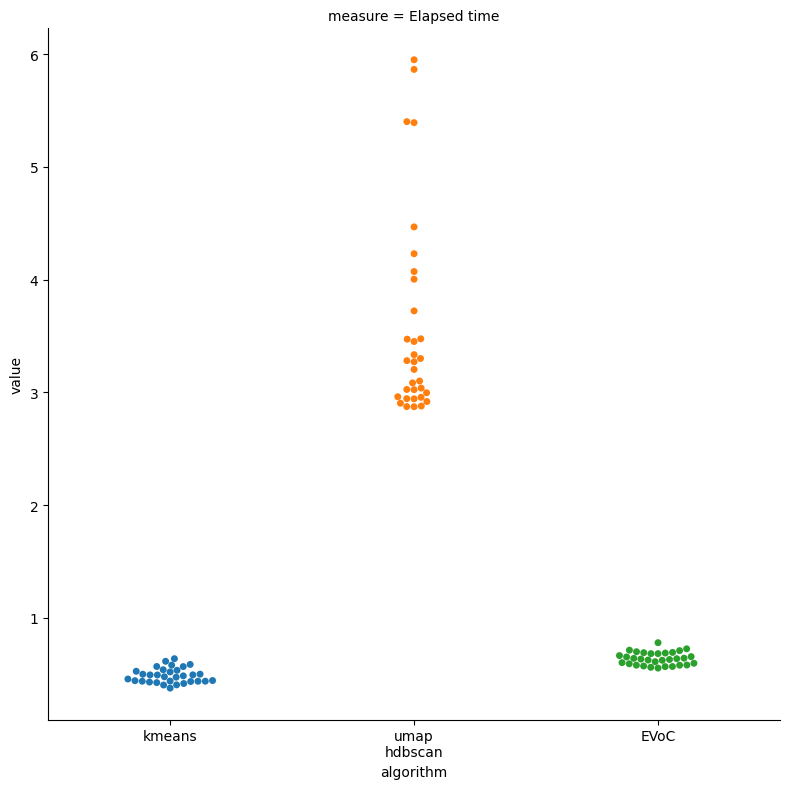

In [14]:
sns.catplot(
    news_results[news_results.measure == "Elapsed time"], 
    x="algorithm", 
    y="value", 
    hue="algorithm", 
    kind="swarm", 
    col="measure",
    height=8,
)

Both KMeans and EVoC produce sub-second timings. This time KMeans has a slight edge in speed, but the distributions overlap, so it is hard to say with confidence that EVoC is significantly slower than KMeans even in this case. UMAP + HDBSCAN was generally much faster than before, but still lags significantly behind the competition in run time. How about quality?

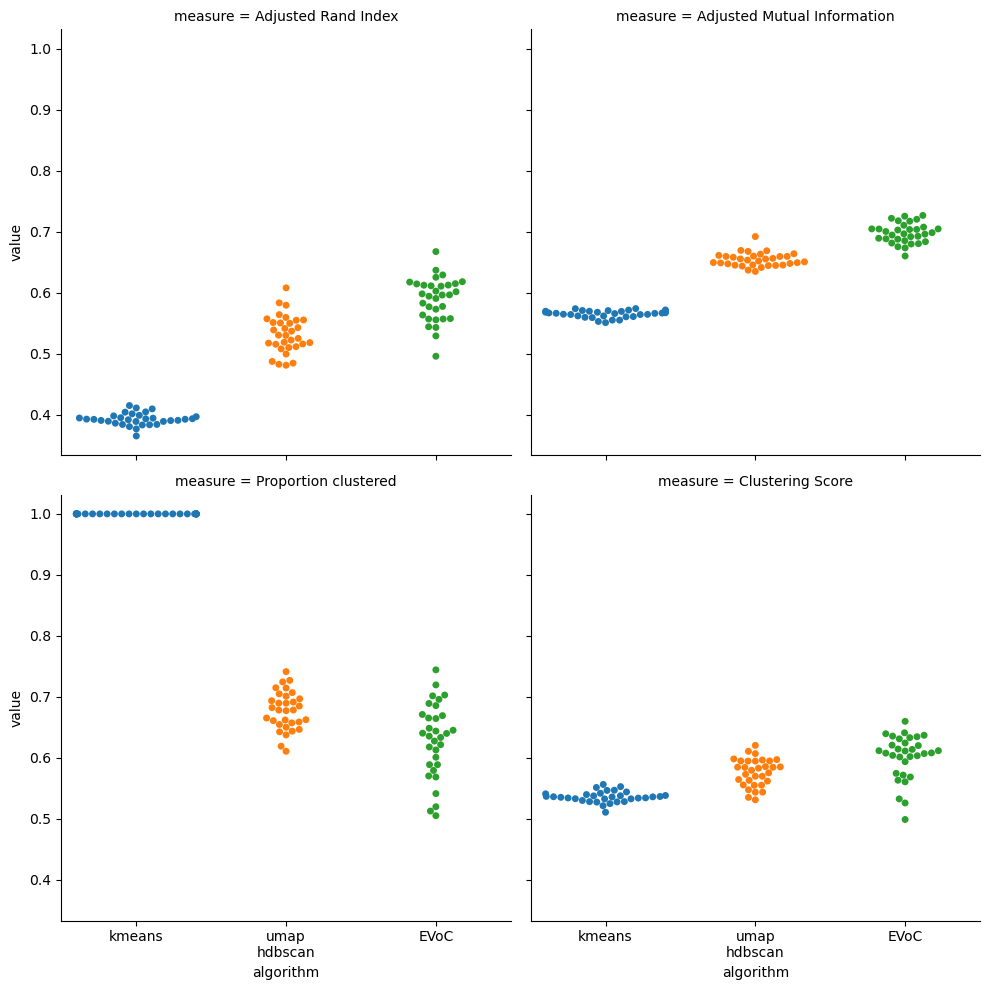

In [15]:
sns.catplot(
    news_results[news_results.measure != "Elapsed time"], 
    x="algorithm", 
    y="value", 
    hue="algorithm", 
    col="measure", 
    kind="swarm", 
    col_wrap=2,
    height=5,
)

Both ARI and AMI scores for all the algorithms are much lower here -- this is a significantly noiser and harder to cluster dataset. Nonetheless KMeans does consistently worse in terms of cluster quality over the points actually clustered by the algorithms. This came at a cost for UMAP + HDBSCAN and EVoC however: they consistently cluster between about 50% and 75% of the dataset and leave a lot of data unclustered as noise. That is to be expected to some degree, but does represent a challenge if you want cluster labels for most of your data. This shows up in the clustering score, with all three approaches being much closer with overlap among the distributions. Still, EVoC has a notable edge in quality overall, and for an approach that ran as fast as KMeans that's quite powerful. 

## Audio embeddings

Audio embedding models are increasingly common. As a test dataset we'll use the BirdCLEF 2023 dataset. This was a kaggle competition for correctly identifying bird species based on audio clips of their songs. Agsin this is quite challenging. The audio is (literally) noisy, with potential for a lot of background noise and even other bird calls intruding into the background of audio clips. We also need a good embedding model representation of this audio id we have any hope that clustering can match against the class labels. Fortunately someone embedded the dataset using Google's Bird Vocalization Classifier and put that data on Huggingface, so we can simply download the embeddings. The dataset has a large number of possible species, and some of those have fewer than 100 recordings, making clustering them quite difficult. To make things a little easier on our clustering algorithms we'll prune out all samples from species that have 100 or fewer recordings in the dataset.

In [16]:
ds_birdclef = load_dataset("Syoy/birdclef_2023_train")
birdclef2023_data = np.asarray(ds_birdclef["train"]["embeddings"])
birdclef2023_target = np.asarray(ds_birdclef["train"]["primary_label"])
# Only use bird species with at least 100 samples -- this is still very challenging
mask = np.isin(
    birdclef2023_target,
    np.where(np.bincount(birdclef2023_target) > 100)[0],
)
birdclef2023_data = birdclef2023_data[mask]
birdclef2023_target = birdclef2023_target[mask]

Now we just need to run all the algorithms. Again runing was required to find the right number of clusters for KMeans to get good results. UMAP + HDBSCAN was a little wasier to tune, as we have a concrete idea of the ``min_cluster_size`` based on our pruning.

In [17]:
bird_results = run_dataset_benchmarks(
    birdclef2023_data, 
    birdclef2023_target, 
    n_runs=16, 
    kmeans_kwargs={"n_clusters":130}, 
    umap_hdbscan_kwargs={
        "min_samples":5,
        "min_cluster_size":100, 
        "metric":"cosine", 
        "cluster_selection_method":"leaf"
    }
)

As always we'll start with timing results.

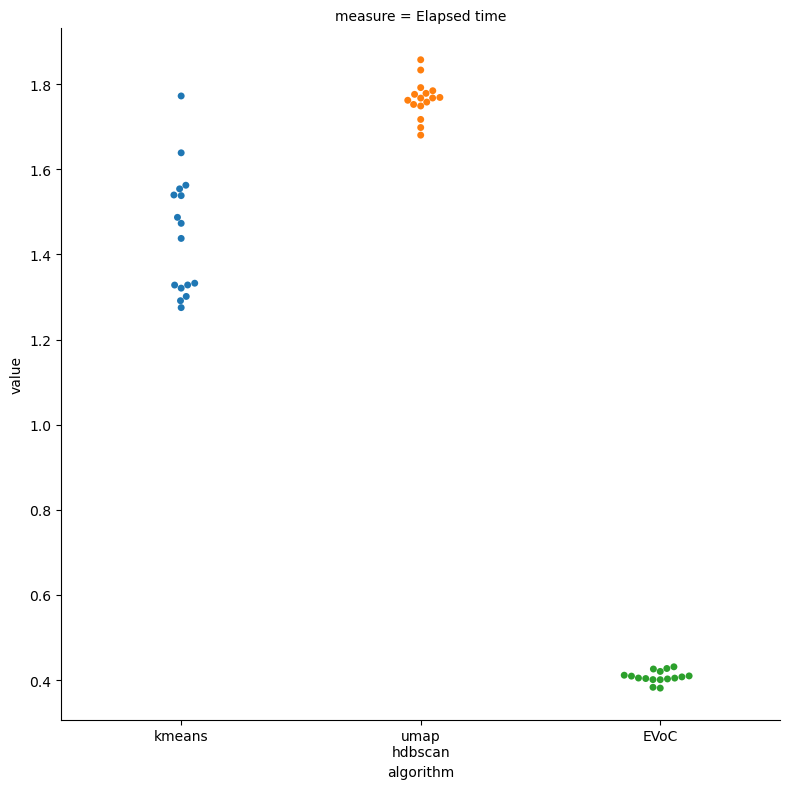

In [18]:
sns.catplot(
    bird_results[bird_results.measure == "Elapsed time"], 
    x="algorithm", 
    y="value", 
    hue="algorithm", 
    kind="swarm", 
    col="measure",
    height=8,
)

This time we have some slightly surprising results: KMeans is only barely faster than UMAP + HDBSCAN. This is a result of the need for a large number of clusters, combined with a smaller overall dataset size, such that UMAP + HDBSCAN can run very quickly. In combination this results in UMAP + HDBSCAN being only slightly slower than KMeans. On the other hand EVoC turned out results extremely quickly -- more than 3 times faster than KMeans. So for pure speed EVoC turns out to be a winner here.

How about clustering quality?

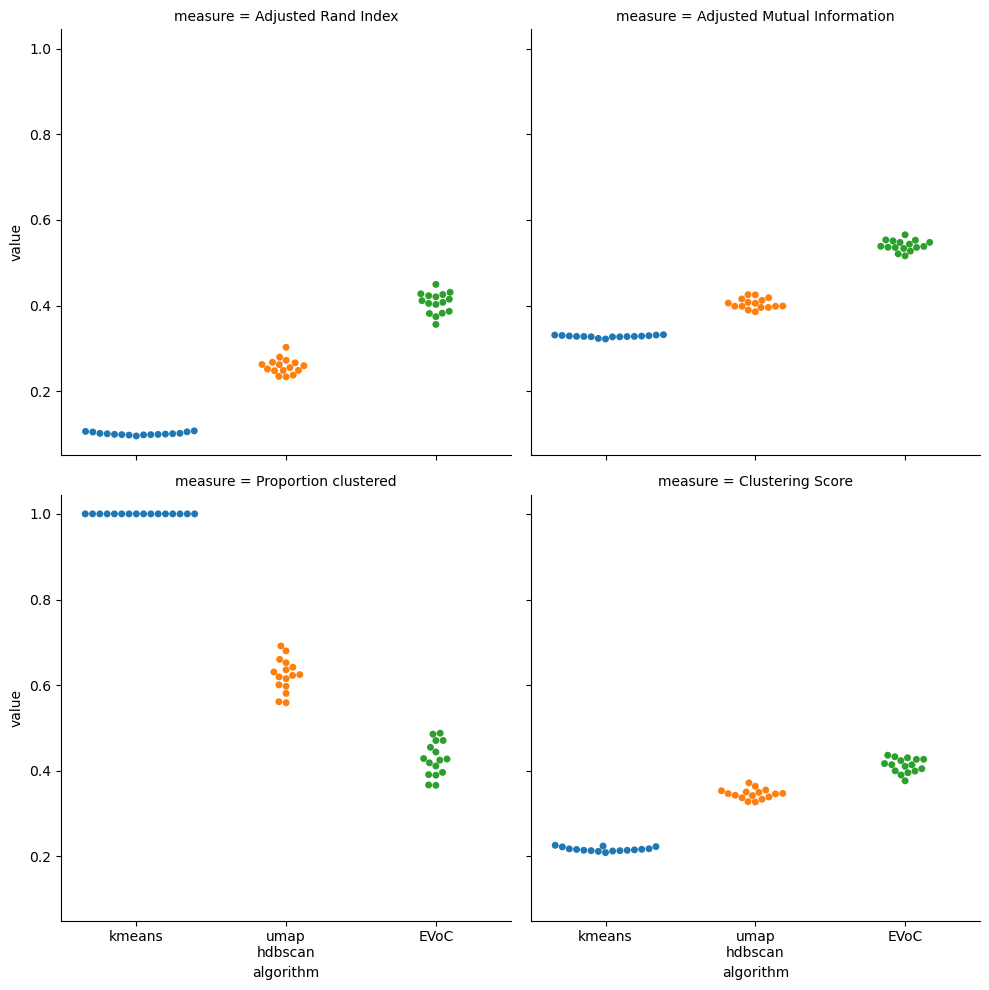

In [19]:
sns.catplot(
    bird_results[bird_results.measure != "Elapsed time"], 
    x="algorithm", 
    y="value", 
    hue="algorithm", 
    col="measure", 
    kind="swarm", 
    col_wrap=2,
    height=5,
)

The first thing to note here is how hard it is o cluster this dataset well. Both ARI and AMI scores in the 0 to 0.6 range represent a poor match against the ground-truth labels. This was a recent (2023) Kaggle challenge dataset though, so we should expect it to be very hard -- and we are trying to get results in an entirely unsupervised fashion. With the relative poor quality overall out of the way, how do the different methods compare? Here EVoC is a clear winner in pure ARI and AMI quality. It got there though by clustering even less of the data than UMAP + HDBSCAN. In fact it often clustered less than half the data. We would rather have clusters that are good, and leave hard to cluster points unclustered than have things forced into clusters just to get good coverage, so we don't necessarily see this as bad. Even accounting for the difference in amount clustered using the clustering score EVoC still comes out ahead. This shows how these algorithms perform when the going gets rough.

## Other high dimensional data

Sometimes you just have high dimensional data that isn't necessarily directly from some neural embedding model. We can still try to cluster it and see if EVoC can do a decent job. To try this out let's use the classic MNIST digits dataset. We know that we *should* be able to find good clusters for this data even just using the raw pixel values. So let's see how we do with EVoC on MNIST data.

In [20]:
from sklearn.datasets import fetch_openml

In [21]:
mnist_ds = fetch_openml('mnist_784')
mnist_data = mnist_ds.data.values.astype(np.float32, order="C")
mnist_target = mnist_ds.target.values.astype(np.uint8)

We can run the benchmarks. This time parameter tuning is a little easier.

In [22]:
mnist_results = run_dataset_benchmarks(
    mnist_data, 
    mnist_target, 
    n_runs=16, 
    kmeans_kwargs={"n_clusters":10}, 
    umap_hdbscan_kwargs={
        "min_samples":5,
        "min_cluster_size":1200, 
        "metric":"cosine", 
        "cluster_selection_method":"leaf"
    }
)

As always let's begin with time taken to compute the clusterings:

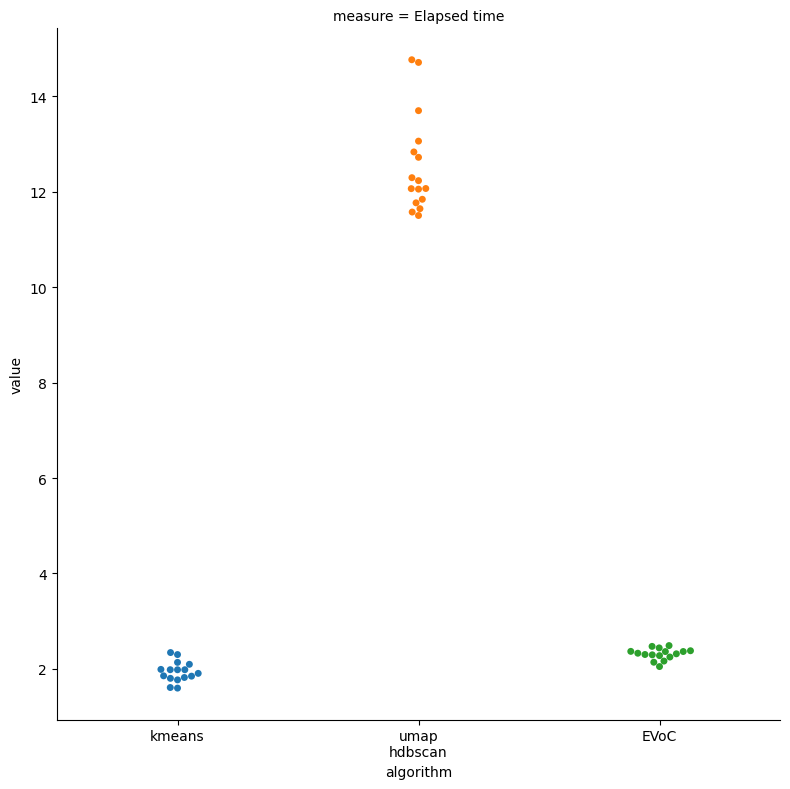

In [23]:
sns.catplot(
    mnist_results[mnist_results.measure == "Elapsed time"], 
    x="algorithm", 
    y="value", 
    hue="algorithm", 
    kind="swarm", 
    col="measure",
    height=8,
)

This produces a pretty dramatic result: UMAP + HDBSCAN take a long time to compute for all 70,000 MNIST digits, while KMeans, as we would expect for large data and a small number of clusters (only ten), takes around two seconds. On the other hand EVoC also comes in at a hair above two seconds to cluster the data. Not quite at KMeans speed, but very close.

How about the clustering quality? This is the kind of high dimensional dataset that KMeans can tend to struggle with.

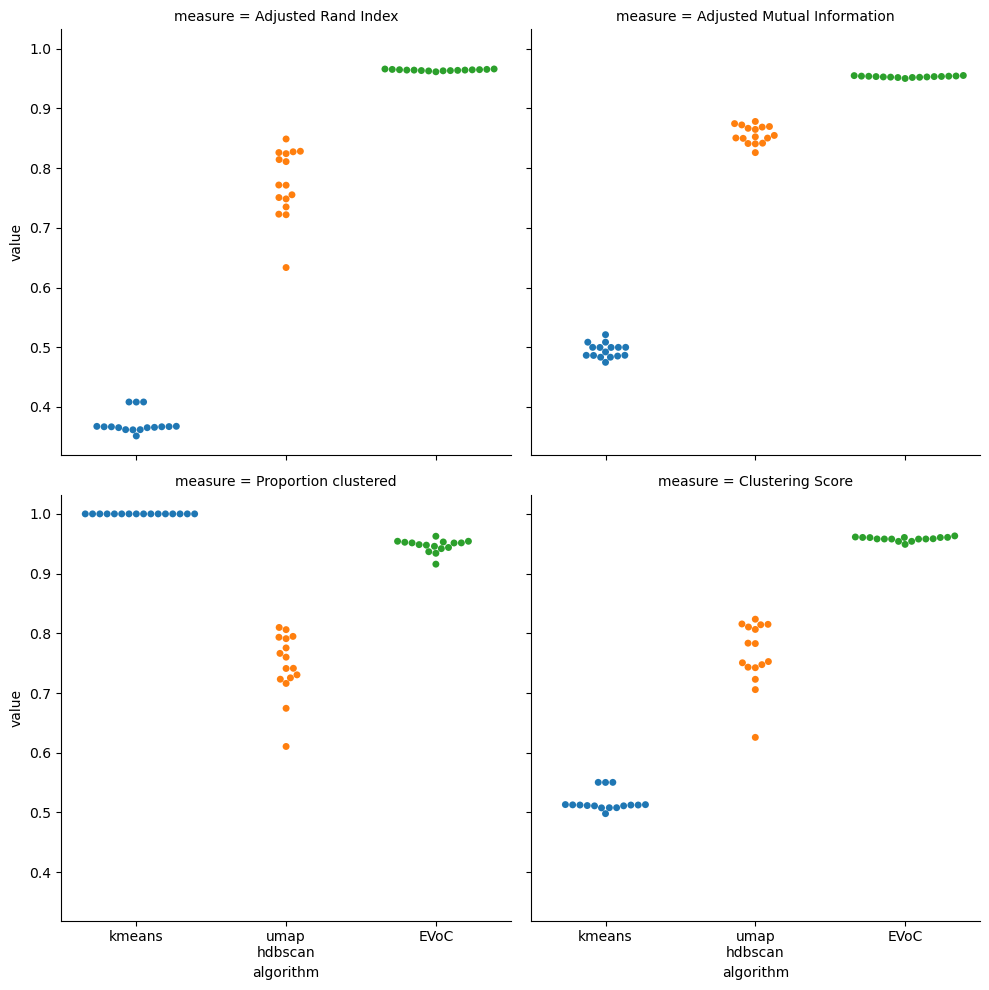

In [30]:
sns.catplot(
    mnist_results[mnist_results.measure != "Elapsed time"], 
    x="algorithm", 
    y="value", 
    hue="algorithm", 
    col="measure", 
    kind="swarm", 
    col_wrap=2,
    height=5,
)

Again we have some very striking results. KMeans does as we would expect, getting low ARI and AMI scores in the 0.4 to 0.5 range. However EVoC manages to get almost perfect scores, and consistently. Better still, EVoC consistently manages to cluster more than 90% of the data. The end result is that even the clustering score shows EVoC head and shoulders above the competition.

So, in summary, EVoC is consistently very very fast to compute, coming in as competitive with, and sometimes faster than, KMeans for small to medium sized datasets. EVoC also consistently produces better quality clusters than the much slower to compute UMAP + HDBSCAN option. And it does all of this with essentially no parameter tuning -- we simply have to pick the best option out of a very small number of layers of cluster resolution. Fast, good, and easy -- sometimes you can have all three.

## Scaling

So far we have looked at small to medium sized datasets of "real-word" data because it comes with class labels we can compare clusterings against, and it provides a realistic challenge for the clusterign algorithms to tackle. EVoC performed very well in tersm of run-time, managing to consistently compete with KMeans. But how well do those results generalize to much larger datasets? Now we are less worried about realistic clusterign challenges, we want to see compute time against dataset size, ideally scaling into millions of data samples. To do that we can use sklearn's ``make_blobs`` to generate some easy to cluster high-dimensional data at varying sample sizes. While we are at it, let's add some extra KMeans implementations into the mix. We'll benchmark FAISS's KMeans, as well as sklean's ``MiniBatchKMeans`` which uses a sampling based approach to do a more approximate optimization at much much faster speeds.

In [25]:
from sklearn.datasets import make_blobs
import faiss

We need similar function wrappers for ``MiniBatchKMeans`` and FAISS: 

In [26]:
def minibatch_kmeans(data, n_clusters=10):
    return sklearn.cluster.MiniBatchKMeans(
        n_clusters=n_clusters, 
        n_init="auto", 
        batch_size=4*n_clusters
    ).fit_predict(
        data
    )

def faiss_kmeans(data, n_clusters=10):
    kmeans = faiss.Kmeans(data.shape[1], n_clusters, niter=50, nredo=1, gpu=False)
    X = np.ascontiguousarray(data, dtype=np.float32)
    kmeans.train(X)
    _, labels = kmeans.index.search(X, 1)
    return labels.ravel()

Now let's just set up a loop and run everything! We'll scale the dataset sizes from 10,000 up to over 3,000,000, have 4 runs of each implementation at each size, and colelct all the results. If you are running this yourself be warned that (since we are clustering millions of samples many times over) this can take a very long time to complete.

In [27]:
algorithms = [
    ("UMAP + HDBSCAN",    lambda X: umap_hdbscan(X)),
    ("Sklearn KMeans",          lambda X: kmeans(X, n_clusters=n_clusters, kmeans_algorithm="elkan")),
    ("FAISS KMeans",    lambda X: faiss_kmeans(X, n_clusters=n_clusters)),
    ("Sklearn Minibatch KMeans",lambda X: minibatch_kmeans(X, n_clusters=n_clusters)),
    ("EVoC",            lambda X: EVoC(X)),
]

scaling_results = {"size": [], "time": [], "algorithm": [], "ari": []}
n_runs = 4

for size in np.logspace(4, 6.5, num=8):
    for n in range(n_runs):
        n_clusters = int(2 * np.sqrt(size))
        blobs, labels = make_blobs(n_samples=int(size), n_features=1024, centers=n_clusters, cluster_std=3.0)
    
        for name, fn in algorithms:
            start_time = time.time()
            clusters = fn(blobs)
            scaling_results["size"].append(size)
            scaling_results["algorithm"].append(name)
            scaling_results["time"].append(time.time() - start_time)
            scaling_results["ari"].append(sklearn.metrics.adjusted_rand_score(labels, clusters))

scaling_df = pd.DataFrame(scaling_results)

Now let's look at the timing results -- how does the runtime scale with increasing dataset size for these different algorithms?

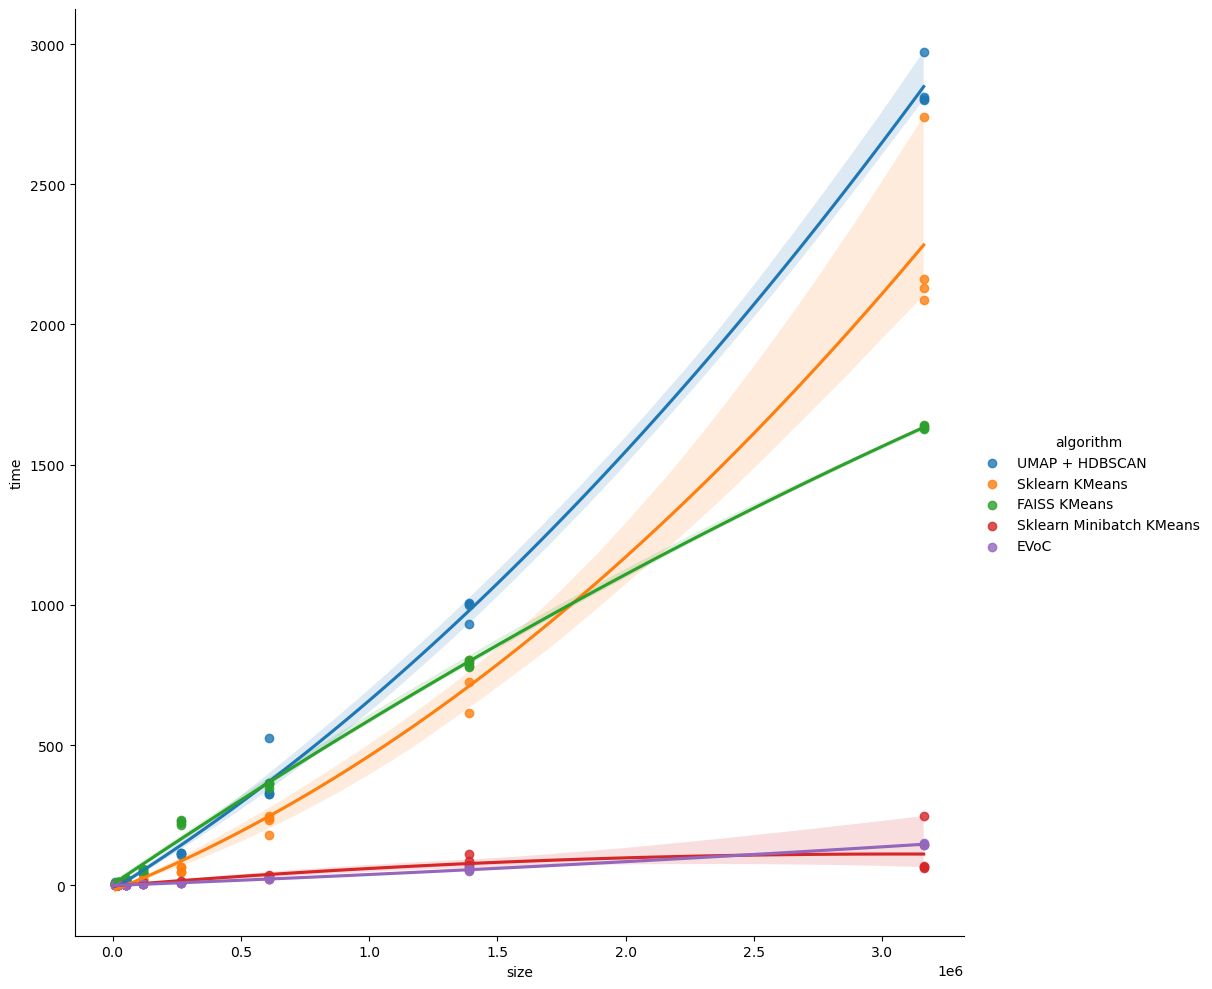

In [28]:
sns.lmplot(data=scaling_df, x="size", y="time", hue="algorithm", order=2, height=10)

Here we see EVoC showing its real strengths. As data set sizes scale up, it comtinues to perform extremely quickly, on par, or even better than, MiniBatchKMeans, and distinctly faster than classic KMeans implementations, including FAISS fast version.

Lastly, let's have a look at quality. We shouldn't expect to see too much here, this is data that should be very easy cluster, so we should expect mostly perfect results. However, some implementations are making trade-offs and approximations, so we should expect to see some of those differences shown here.

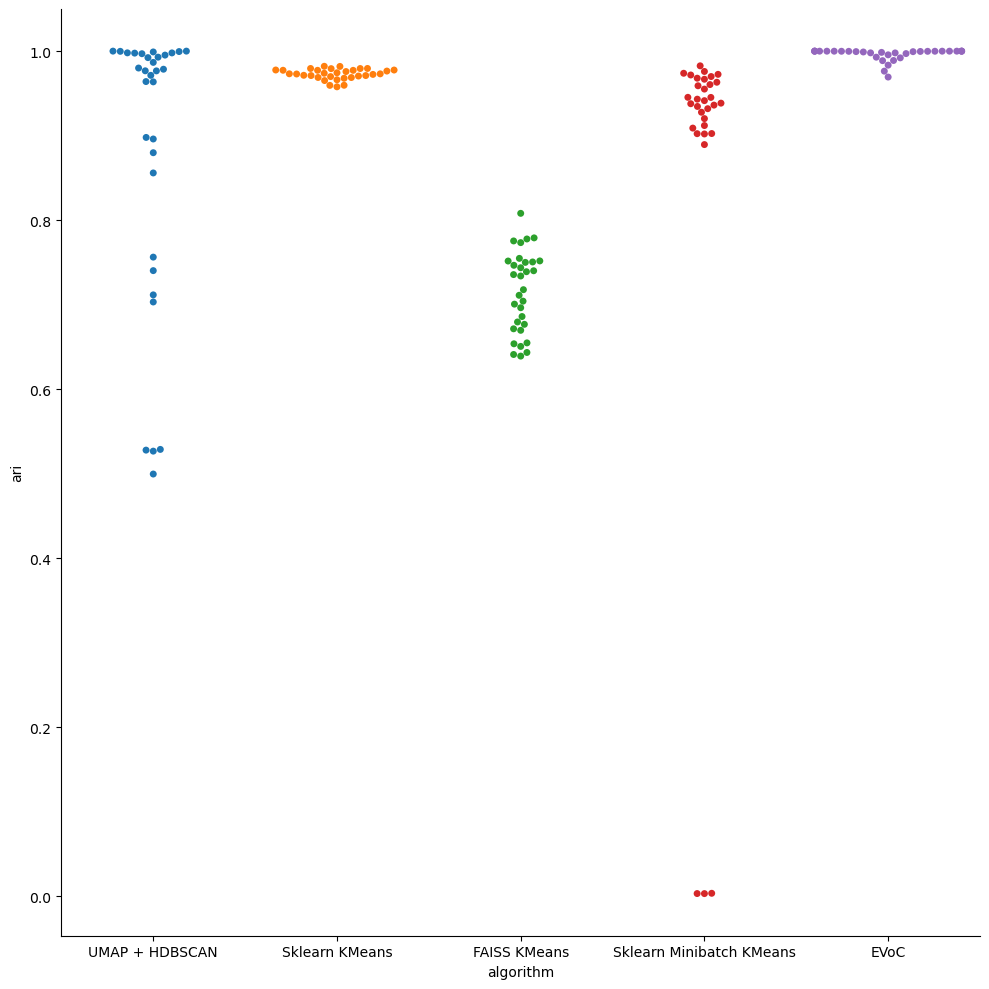

In [29]:
sns.catplot(data=scaling_df, x="algorithm", y="ari", hue="algorithm", kind="swarm", height=10)

The results are pretty clear. The UMAP + HDBSCAN approach mostly produces good clusters -- the decay in quality is essentially down to having run with default parameters which need to be adjusted somewhat for the larger dataset sizes (we weren't doing any parameter tuning). KMeans mostly manages to find the right clusters. FAISS's Kmeans was possibly not well tuned. MiniBatchKMeans shows a lot more variability than KMeans (as we would expect) including some very poor results occasionally; it might be worth it if you need the speed, but it definitely has costs in terms of cluster quality. Lstly, however, we have EVoC which, despite keeping pace with MiniBatchKMeans in compute time the whole way, also manages to produce almost perfect clusterings every time.